## Project Overview


In [8]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets
from nilearn.image import resample_to_img, load_img
from nilearn.maskers import NiftiLabelsMasker, NiftiMasker
from nilearn import plotting
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

In [9]:
img = nib.load("../data/raw/sub--011/func/sub-011_task-rest_run-01_bold.nii.gz")

print("Dimensiones fMRI:", img.shape)

Dimensiones fMRI: (186, 186, 123, 256)


## Cargar atlas Schaefer (original, MNI152)

Se carga el atlas de Schaefer con 100 regiones parceladas según las 7 redes de Yeo. El atlas está en espacio MNI152, mientras que nuestros datos están en MNI305. En lugar de resamplear las 100 ROIs (que provocaba pérdida de regiones), vamos a agrupar primero las ROIs por red y resamplear solo las 7 máscaras resultantes.

In [10]:
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
atlas_img = nib.load(atlas.maps)
print("Atlas Schaefer cargado (MNI152)")

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\Usuario\nilearn_data\schaefer_2018

Atlas Schaefer cargado (MNI152)


## Construir máscaras binarias para las 7 RSNs (en MNI152)

El atlas contiene una imagen (atlas_img) donde cada voxel tiene un número de ROI (1..100). Además, la propiedad atlas.labels indica a qué red de Yeo pertenece cada ROI. Creamos una máscara por red: 1 si el voxel pertenece a alguna ROI de esa red, 0 en caso contrario.

In [12]:
# Obtener los datos del atlas (asumiendo que 'atlas_img' ya está cargado)
atlas_data = atlas_img.get_fdata().astype(int)

# Mapeo de nombre de red a número
net_name_to_number = {
    'Vis': 1,
    'SomMot': 2,
    'DorsAttn': 3,
    'SalVentAttn': 4,
    'Limbic': 5,
    'Cont': 6,
    'Default': 7
}

all_labels = atlas.labels
roi_to_network = {}

for i, label in enumerate(all_labels[1:], start=1):
    parts = label.split('_')
    net_name = None
    for part in parts:
        if part in net_name_to_number:
            net_name = part
            break
    if net_name is not None:
        roi_to_network[i] = net_name_to_number[net_name]

# Inicializar máscaras (7 imágenes 3D)
mask_3d_shape = atlas_data.shape
masks = {net: np.zeros(mask_3d_shape, dtype=np.uint8) for net in range(1, 8)}

# Asignar voxeles a cada red
for roi, net in roi_to_network.items():
    masks[net][atlas_data == roi] = 1

# Convertir a imágenes Nifti (en MNI152)
from nibabel import Nifti1Image
mask_imgs = {net: Nifti1Image(masks[net], affine=atlas_img.affine) for net in range(1,8)}

In [13]:
# Invertir el diccionario para obtener el nombre a partir del número
number_to_name = {v: k for k, v in net_name_to_number.items()}

# Verificar todas las redes
for net in range(1, 8):
    total_voxels = np.sum(masks[net])
    print(f"Red {net} ({number_to_name[net]}): {total_voxels} vóxeles activos")

Red 1 (Vis): 181777 vóxeles activos
Red 2 (SomMot): 128983 vóxeles activos
Red 3 (DorsAttn): 159456 vóxeles activos
Red 4 (SalVentAttn): 108704 vóxeles activos
Red 5 (Limbic): 92104 vóxeles activos
Red 6 (Cont): 123444 vóxeles activos
Red 7 (Default): 261217 vóxeles activos


## Plot de las redes y visualización de ellas mediante gráficas

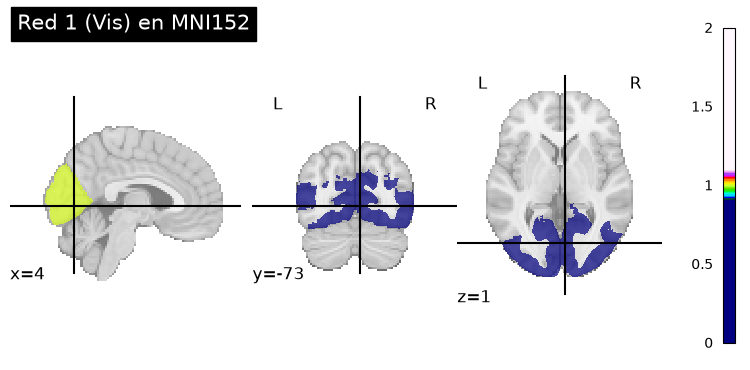

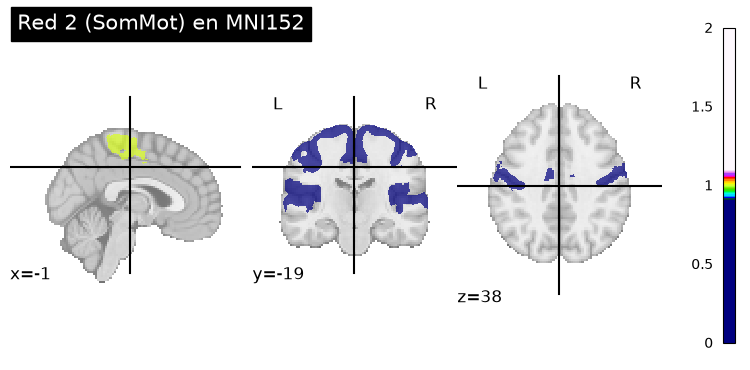

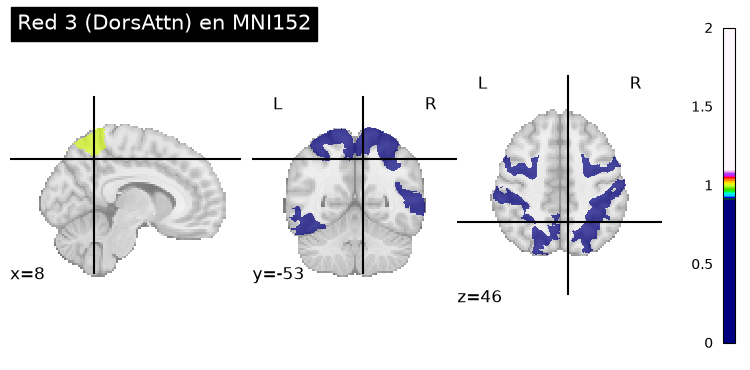

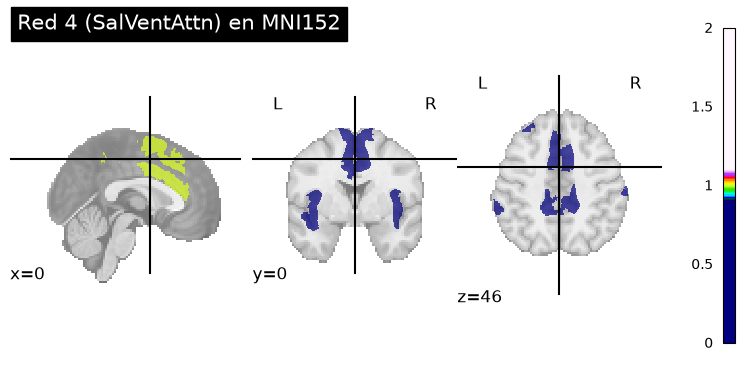

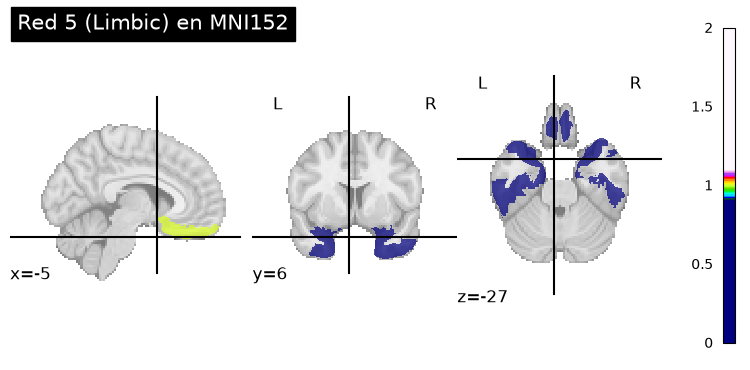

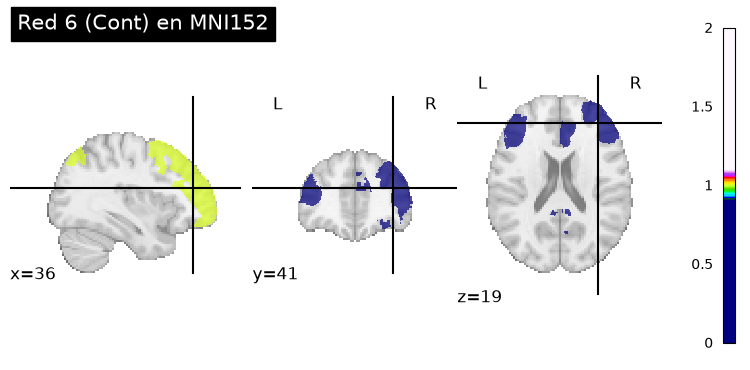

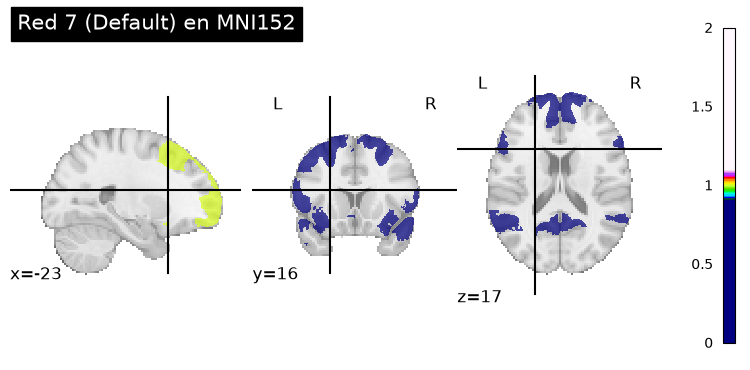

In [6]:
# Invertir el diccionario si no lo tienes ya
number_to_name = {v: k for k, v in net_name_to_number.items()}

# Plot de cada red
for net in range(1, 8):
    plotting.plot_roi(
        mask_imgs[net],
        title=f"Red {net} ({number_to_name[net]}) en MNI152"
    )
    plotting.show()

## Coregistro de las plantillas espaciales (MNI152 → MNI305) y transformación de las máscaras de las 7 RSNs

Para transformar correctamente las máscaras de las redes desde el espacio original del atlas (MNI152) al espacio de nuestros datos fMRI (MNI305), es necesario calcular una **matriz de transformación afín** que alinee ambas plantillas anatómicas. Este método es mucho más preciso que el simple `resample_to_img`, ya que modela rotaciones, traslaciones, escalas y sesgos.

Se procede en dos etapas:
1. **Registro rígido** (6 grados de libertad): alinea groseramente las imágenes utilizando información mutua.
2. **Registro afín** (12 grados de libertad): refina el alineamiento permitiendo escalado y sesgo.

Una vez obtenida la transformación final, se aplica a cada máscara binaria de red (MNI152) usando interpolación `nearest` para preservar su naturaleza binaria (0/1). El resultado son las máscaras coregistradas en espacio MNI305, listas para la extracción de señales.

**Plantillas utilizadas:**
- Fuente (MNI152): `mni_icbm152_t1_tal_nlin_sym_09a.nii`
- Destino (MNI305): `average305_t1_tal_lin.nii`

In [14]:
# ------------------------------------------------------------
# Usar el atlas transformado por tutor (ya en MNI305)
# ------------------------------------------------------------
ruta_atlas_tutor = "C:/Users/Usuario/Desktop/UNIVERSIDAD/MÁSTER/TFM/Code/rsn_predictions/data/extra/schaefer_average305_t1_tal_lin.nii.gz"
ruta_mni152 = "C:/Users/Usuario/Desktop/UNIVERSIDAD/MÁSTER/TFM/Code/rsn_predictions/models/mni_icbm152_nlin_sym_09a_nifti/mni_icbm152_nlin_sym_09a/mni_icbm152_t1_tal_nlin_sym_09a.nii"
ruta_mni305 = "C:/Users/Usuario/Desktop/UNIVERSIDAD/MÁSTER/TFM/Code/rsn_predictions/models/mni305_lin_nifti/average305_t1_tal_lin.nii"
atlas_tutor_img = nib.load(ruta_atlas_tutor)
atlas_tutor_data = atlas_tutor_img.get_fdata().astype(int)

# Construir máscaras de las 7 redes (usando el mismo mapeo roi_to_network)
mask_imgs_tutor = {}
for net in range(1, 8):
    mask_net = np.zeros(atlas_tutor_data.shape, dtype=np.uint8)
    for roi, red in roi_to_network.items():
        if red == net:
            mask_net[atlas_tutor_data == roi] = 1
    mask_imgs_tutor[net] = nib.Nifti1Image(mask_net, atlas_tutor_img.affine)

print("Máscaras construidas a partir del atlas del tutor (espacio MNI305).")

Máscaras construidas a partir del atlas del tutor (espacio MNI305).


In [15]:
import pickle
pickle.dump(mask_imgs_tutor, open('mask_imgs_tutor.pkl', 'wb'))

In [16]:
print("Vóxeles activos antes (MNI152) y después (MNI305) del resample:")
for net in range(1,8):
    antes = np.sum(masks[net])
    despues = np.sum(mask_imgs_tutor[net].get_fdata().astype(int))
    print(f"Red {net}: antes={antes}, después={despues}, retención={despues/antes*100:.1f}%")

Vóxeles activos antes (MNI152) y después (MNI305) del resample:
Red 1: antes=181777, después=171810, retención=94.5%
Red 2: antes=128983, después=129294, retención=100.2%
Red 3: antes=159456, después=159353, retención=99.9%
Red 4: antes=108704, después=102382, retención=94.2%
Red 5: antes=92104, después=92618, retención=100.6%
Red 6: antes=123444, después=121264, retención=98.2%
Red 7: antes=261217, después=252104, retención=96.5%


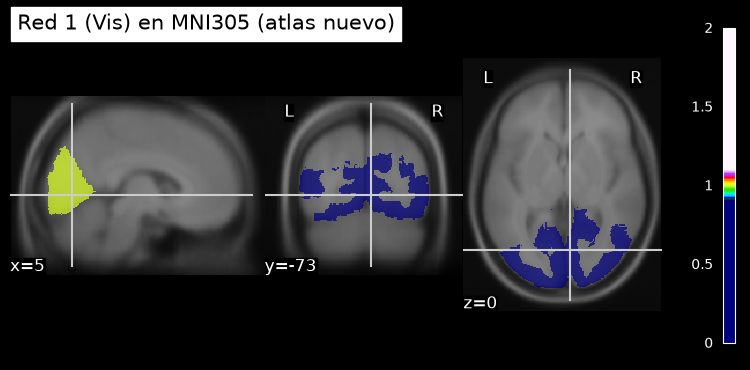

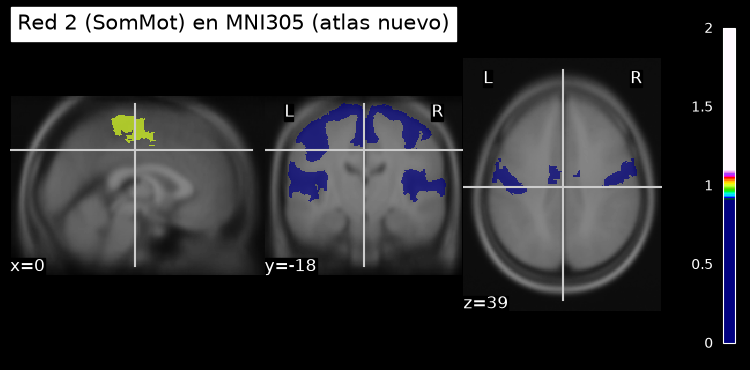

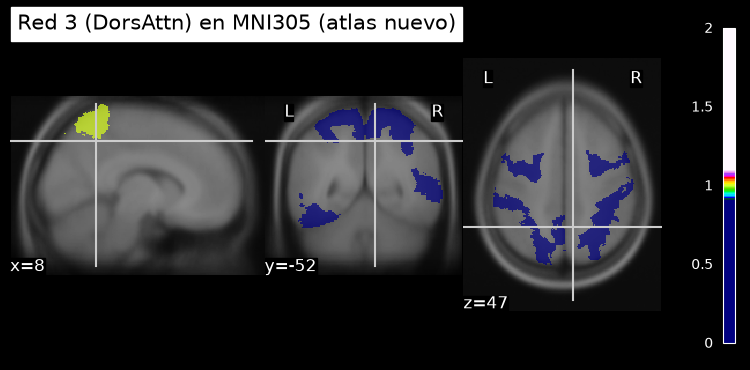

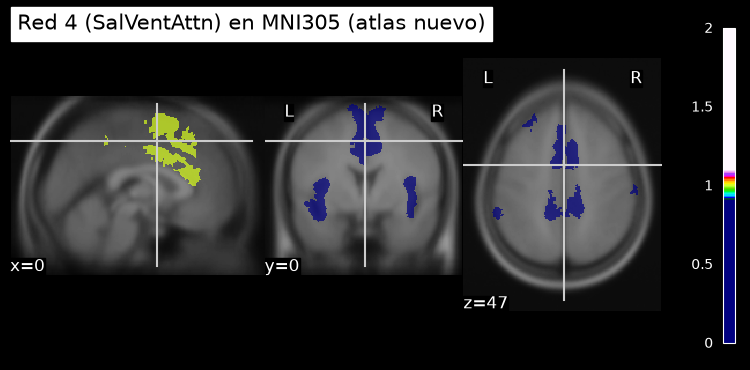

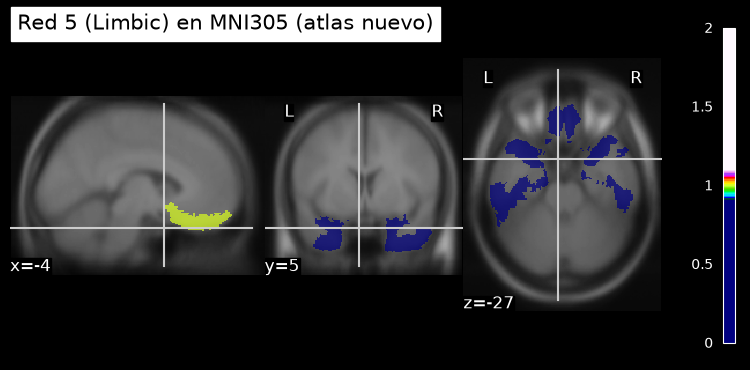

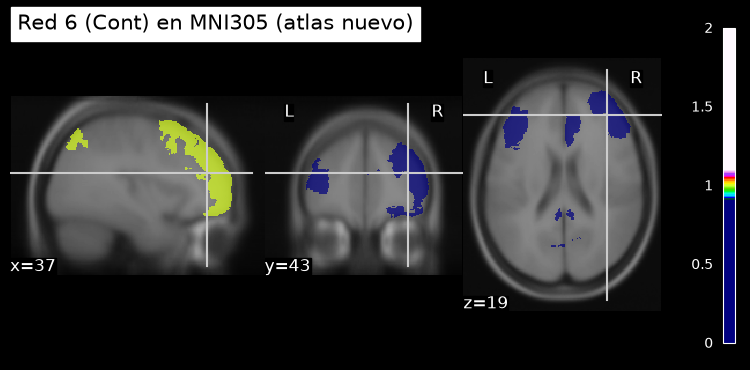

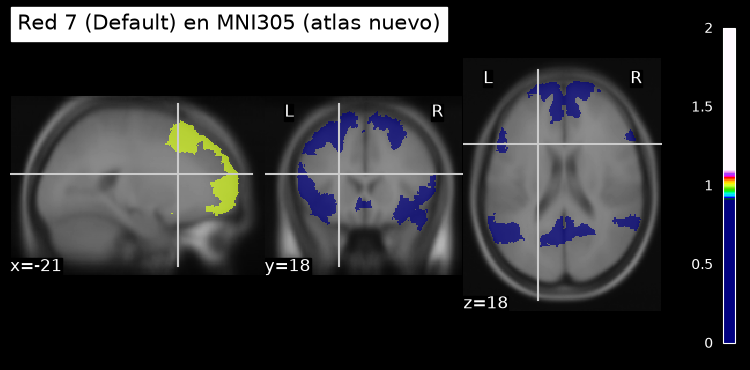

In [12]:
plantilla_mni305 = nib.load(ruta_mni305)
for net in range(1, 8):
    plotting.plot_roi(mask_imgs_tutor[net], bg_img=plantilla_mni305,
                      title=f"Red {net} ({number_to_name[net]}) en MNI305 (atlas nuevo)")
    plotting.show()

In [17]:
img = nib.load("../data/raw/sub--011/func/sub-011_task-rest_run-01_bold.nii.gz")

print(mask_imgs_tutor.keys())

dict_keys([1, 2, 3, 4, 5, 6, 7])


## Extraer señales de las 7 redes con filtrado (detrend, paso banda)

Se extrae la señal BOLD promedio para cada una de las 7 redes. Se aplica:

detrend=True para eliminar derivas lineales.

standardize=True (z-score) para que todas las redes sean comparables.

Filtro paso banda 0.01–0.1 Hz (elimina ruido fisiológico y derivas muy lentas).

Suavizado espacial de 6 mm FWHM para reducir ruido.
El resultado son 7 series temporales normalizadas.

Para visualizar el efecto del z-score, extraemos una red sin estandarizar

In [22]:
TR = 2.5
time_series_red = {}

for net in range(1, 8):
    masker = NiftiMasker(
        mask_img=mask_imgs_tutor[net],   # ← ÚNICO CAMBIO
        detrend=True,
        standardize='zscore_sample',
        low_pass=0.1,
        high_pass=0.01,
        t_r=TR,
        verbose=0
    )
    ts_voxels = masker.fit_transform(img)
    ts_mean = ts_voxels.mean(axis=1)
    time_series_red[net] = ts_mean

time_series = np.column_stack([time_series_red[net] for net in range(1, 8)])
print("Shape señales (tiempo, redes):", time_series.shape)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21632\1760714846.py:14: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  ts_voxels = masker.fit_transform(img)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_21632\1760714846.py:14: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  ts_voxels = masker.fit_transform(img)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_21632\1760714846.py:14: UserWarning: Casting data from int16 to float32
  ts_voxels = masker.fit_transform(img)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_21632\1760714846.py:14: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be

Shape señales (tiempo, redes): (256, 7)


In [23]:
print("Estadísticas de time_series (por red):")
print("Media:", time_series.mean(axis=0))
print("Desviación estándar:", time_series.std(axis=0))
print("Valor mínimo:", time_series.min(axis=0))
print("Valor máximo:", time_series.max(axis=0))

Estadísticas de time_series (por red):
Media: [-9.6156327e-10  2.2282620e-10 -3.4151526e-10  1.0004442e-09
 -1.0004442e-09 -1.5024852e-09 -1.9754225e-09]
Desviación estándar: [0.01796886 0.05452306 0.03255064 0.09320063 0.08921858 0.08358341
 0.07479384]
Valor mínimo: [-0.0769714  -0.2178337  -0.16924225 -0.49198985 -0.36493102 -0.39896637
 -0.4179936 ]
Valor máximo: [0.04571288 0.13273227 0.08736976 0.27348766 0.26849398 0.27023515
 0.1933209 ]


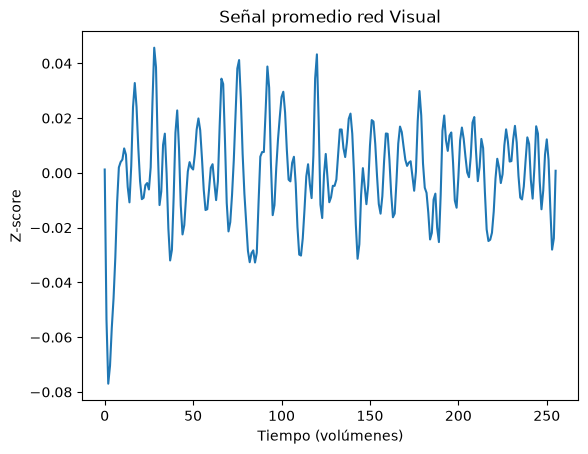

In [24]:
import matplotlib.pyplot as plt
plt.plot(time_series[:, 0])   # red 1 (Visual)
plt.title('Señal promedio red Visual')
plt.xlabel('Tiempo (volúmenes)')
plt.ylabel('Z-score')
plt.show()

## Gráfica: señal antes y después de z-score

Para visualizar el efecto del z-score, extraemos una red sin estandarizar.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21632\1867108597.py:3: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  ts_raw = masker_raw.fit_transform(img).flatten()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_21632\1867108597.py:3: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  ts_raw = masker_raw.fit_transform(img).flatten()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_21632\1867108597.py:3: UserWarning: Casting data from int16 to float32
  ts_raw = masker_raw.fit_transform(img).flatten()


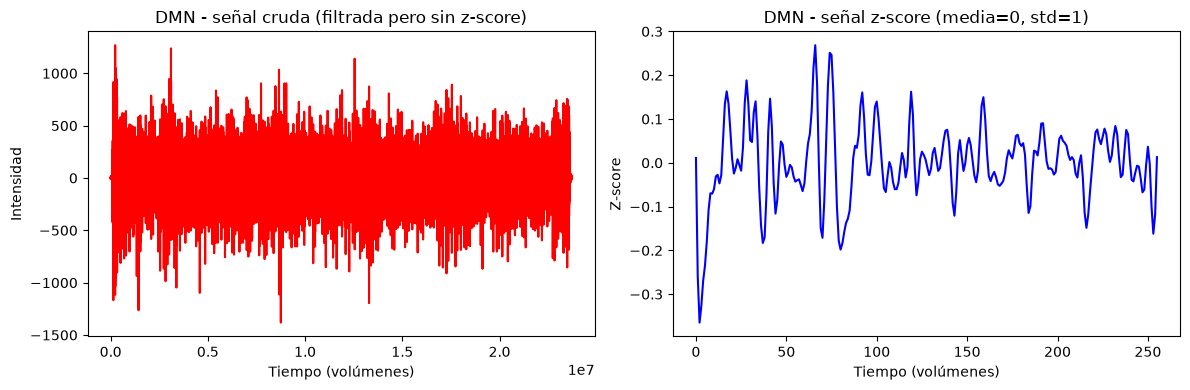

In [25]:
# Extraer señal de la red 5 (DMN) sin estandarizar
masker_raw = NiftiMasker(mask_img=mask_imgs_tutor[5], detrend=True, standardize=False, low_pass=0.1, high_pass=0.01, t_r=TR)
ts_raw = masker_raw.fit_transform(img).flatten()

# La señal ya estandarizada está en time_series[:,4] (red 5)
ts_norm = time_series[:,4]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ts_raw, color='red')
plt.title("DMN - señal cruda (filtrada pero sin z-score)")
plt.xlabel("Tiempo (volúmenes)")
plt.ylabel("Intensidad")
plt.subplot(1,2,2)
plt.plot(ts_norm, color='blue')
plt.title("DMN - señal z-score (media=0, std=1)")
plt.xlabel("Tiempo (volúmenes)")
plt.ylabel("Z-score")
plt.tight_layout()
plt.show()

La señal cruda tiene media distinta de cero y mayor variabilidad. Tras el z-score, ambas redes quedan en la misma escala, facilitando la comparación y la definición de un umbral común.

In [26]:
# Normalizar cada columna (red) por separado
time_series_norm = (time_series - time_series.mean(axis=0)) / time_series.std(axis=0)

# Verificar que ahora la desviación es 1
print("Nueva desviación estándar por red:", time_series_norm.std(axis=0))
print("Nuevos máximos:", time_series_norm.max(axis=0))

Nueva desviación estándar por red: [0.9999997 1.0000001 1.0000001 1.0000005 1.        1.        0.9999999]
Nuevos máximos: [2.5440056 2.4344246 2.6841178 2.934397  3.0093954 3.2331195 2.584717 ]


In [27]:
import pickle
with open('time_series_coreg.pkl', 'wb') as f:
    pickle.dump(time_series, f)
with open('time_series_norm_coreg.pkl', 'wb') as f:
    pickle.dump(time_series_norm, f)
print("Variables guardadas.")

Variables guardadas.


## Point process (binarización con umbral de 1 SD)

Se define un evento (red activa) cuando su señal normalizada supera +1 desviación típica. Como la señal tiene media 0 y std 1, este umbral corresponde a activaciones fuertes (>1σ). El resultado es una secuencia binaria de 7 bits por cada instante.

In [28]:
threshold_sd = 1.0   # 1 desviación típica
binary_states = (time_series_norm > threshold_sd).astype(int)
print("Estados binarios shape:", binary_states.shape)  # (256, 7)

event_rates = binary_states.mean(axis=0)
for i, rate in enumerate(event_rates, 1):
    print(f"Red {i}: {rate*100:.1f}% de instantes activos")

Estados binarios shape: (256, 7)
Red 1: 13.3% de instantes activos
Red 2: 13.7% de instantes activos
Red 3: 10.5% de instantes activos
Red 4: 9.0% de instantes activos
Red 5: 12.1% de instantes activos
Red 6: 12.1% de instantes activos
Red 7: 9.4% de instantes activos


In [29]:
import pickle
with open('time_series_norm.pkl', 'wb') as f:
    pickle.dump(time_series_norm, f)
with open('binary_states.pkl', 'wb') as f:
    pickle.dump(binary_states, f)
print("Variables guardadas")

Variables guardadas


## Distribución de estados conjuntos (novedad)

Se calcula la frecuencia de cada uno de los 2^7 = 128 posibles patrones de activación. La distribución no es uniforme: algunos estados aparecen mucho más que otros, lo que indica que la actividad cerebral en reposo no es aleatoria y tiene una estructura preferente. Esto respalda la hipótesis de que existen patrones temporales no estocásticos.

In [30]:
import plotly.graph_objects as go
import numpy as np

# Calcular códigos de estado y frecuencias (suponiendo que binary_states ya existe)
weights = 2**np.arange(6, -1, -1)
state_codes = binary_states @ weights
unique, counts = np.unique(state_codes, return_counts=True)

# Filtrar el estado 0
mask_no_zero = unique != 0
unique_filt = unique[mask_no_zero]
counts_filt = counts[mask_no_zero]

# Máximo para el eje Y
y_max_global = max(counts_filt) if len(counts_filt) > 0 else 1

# Función para el hover text
def state_description(code):
    bits = [(code >> i) & 1 for i in range(6, -1, -1)]
    active_networks = [number_to_name[j] for j, bit in enumerate(bits, start=1) if bit]
    if not active_networks:
        return "Ninguna red activa"
    return " + ".join([f"Red {j} ({name})" for j, name in enumerate(active_networks, start=1)])

# Hover text (sin texto en las barras)
hover_texts = [f"Código: {code}<br>Redes activas: {state_description(code)}<br>Frecuencia: {count}" 
               for code, count in zip(unique_filt, counts_filt)]

# Crear figura SIN texto en las barras
fig = go.Figure(data=go.Bar(
    x=unique_filt,
    y=counts_filt,
    hovertext=hover_texts,
    hoverinfo='text',
    marker_color='steelblue',
    width=0.98          # barras más anchas (ocupan casi todo el espacio disponible)
))

# Ajustes del layout
fig.update_layout(
    title="Distribución de estados (umbral 1 SD) - sin estado 0",
    xaxis_title="Estado (código decimal de 7 bits)",
    yaxis_title="Frecuencia",
    yaxis=dict(range=[0, y_max_global]),
    width=1200,          # figura más ancha
    height=500,
    bargap=0.02          # espacio mínimo entre barras (para que sean más anchas)
)

fig.show()
# Guardar como HTML (interactivo)
fig.write_html("plot1.html")

## Comparación del point process con distintos umbrales (0.5 SD / 1 SD / 1.5 SD / 2 SD)

Ejecutamos el point process y mostramos las gráficas para comparar

In [31]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Función de hover (idéntica a la del ejemplo individual)
def state_description(code):
    bits = [(code >> i) & 1 for i in range(6, -1, -1)]
    active_networks = [number_to_name[j] for j, bit in enumerate(bits, start=1) if bit]
    if not active_networks:
        return "Ninguna red activa"
    return " + ".join([f"Red {j} ({name})" for j, name in enumerate(active_networks, start=1)])

umbrales = [0.5, 1.0, 1.5, 2.0]

# Calcular el máximo global de frecuencias (sin contar estado 0)
y_max_global = 0
for th in umbrales:
    binary = (time_series_norm > th).astype(int)
    weights = 2**np.arange(6, -1, -1)
    state_codes = binary @ weights
    unique, counts = np.unique(state_codes, return_counts=True)
    mask_no_zero = unique != 0
    counts_filt = counts[mask_no_zero]
    if len(counts_filt) > 0:
        y_max_global = max(y_max_global, max(counts_filt))

print(f"Máximo global de frecuencias (sin estado 0): {y_max_global}")

# Crear subplots 2x2
fig = make_subplots(rows=2, cols=2, subplot_titles=[f"Umbral {th} SD" for th in umbrales])

for idx, th in enumerate(umbrales):
    binary = (time_series_norm > th).astype(int)
    weights = 2**np.arange(6, -1, -1)
    state_codes = binary @ weights
    unique, counts = np.unique(state_codes, return_counts=True)

    # Filtrar estado 0
    mask_no_zero = unique != 0
    unique_filt = unique[mask_no_zero]
    counts_filt = counts[mask_no_zero]

    # Hover text (sin texto en las barras)
    hover_texts = [f"Código: {code}<br>Redes activas: {state_description(code)}<br>Frecuencia: {count}"
                   for code, count in zip(unique_filt, counts_filt)]

    row, col = idx // 2 + 1, idx % 2 + 1
    fig.add_trace(
        go.Bar(
            x=unique_filt,
            y=counts_filt,
            hovertext=hover_texts,
            hoverinfo='text',
            marker_color='steelblue',
            width=0.98          # barras más anchas
        ),
        row=row, col=col
    )
    fig.update_xaxes(title_text="Estado (código decimal)", range=[0.5, 128], row=row, col=col)
    fig.update_yaxes(title_text="Frecuencia", range=[0, y_max_global], row=row, col=col)

# Ajustes globales (igual que en la gráfica individual)
fig.update_layout(
    height=800,
    width=1200,
    showlegend=False,
    title_text="Distribución de estados (sin estado 0)",
    bargap=0.02
)

fig.show()
fig.write_html("plot2.html")

Máximo global de frecuencias (sin estado 0): 27


In [32]:
import pickle

# Guardar state_codes (secuencia de tokens que usará el Transformer)
with open('state_codes.pkl', 'wb') as f:
    pickle.dump(state_codes, f)

print("state_codes guardado en state_codes.pkl")

state_codes guardado en state_codes.pkl


In [33]:
import os
print(os.listdir())  # Deberías ver 'state_codes.pkl'

['.gitignore', '.gitkeep', 'binary_states.pkl', 'corr_lag1.csv', 'corr_lag2.csv', 'figures', 'mask_imgs_coregistradas.pkl', 'mask_imgs_tutor.pkl', 'network_analysis.py', 'Notebook1.ipynb', 'Notebook1.md', 'Notebook1_files', 'Notebook2.ipynb', 'Notebook2.md', 'Notebook2_files', 'Notebook3.ipynb', 'Notebook3.md', 'Notebook3_files', 'Notebook4.ipynb', 'Notebook4.md', 'Notebook4_files', 'Notebook5.ipynb', 'Notebook5.md', 'plot1.html', 'plot2.html', 'processing_errors_20260820_111506.log', 'processing_errors_20260820_111920.log', 'processing_errors_20260820_112004.log', 'processing_errors_20260820_112025.log', 'processing_errors_20260820_112046.log', 'processing_errors_20260820_112158.log', 'processing_errors_20260820_112311.log', 'processing_errors_20260820_112715.log', 'processing_errors_20260821_170357.log', 'processing_errors_20260821_170450.log', 'processing_errors_20260821_200614.log', 'processing_errors_20260822_003617.log', 'processing_errors_20260822_004548.log', 'processing_errors

## Preparación del dataset temporal y modelo predictivo (igual que Notebook1 pero con 7 redes)

Se repite el mismo análisis predictivo que en el Notebook1, pero ahora con 7 estados binarios (uno por red) y con el point process corregido. La evaluación en test (futuro no visto) permite valorar si la estructura temporal detectada es generalizable.

In [25]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

umbrales = [0.5, 1.0, 1.5, 2.0]
resultados = []

for th in umbrales:
    # 1. Generar estados binarios
    binary = (time_series_norm > th).astype(int)
    
    # 2. Preparar dataset temporal
    X = binary[:-1]
    y = binary[1:]
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # 3. Entrenar y predecir (1 modelo por red)
    y_pred_test = np.zeros_like(y_test)
    for i in range(7):
        unique_classes = np.unique(y_train[:, i])
        if len(unique_classes) < 2:
            # Solo una clase en entrenamiento → predecir siempre esa clase
            y_pred_test[:, i] = unique_classes[0]
        else:
            model = LogisticRegression(max_iter=1000, class_weight='balanced')
            model.fit(X_train, y_train[:, i])
            y_pred_test[:, i] = model.predict(X_test)
    
    # 4. Métricas
    acc = accuracy_score(y_test.flatten(), y_pred_test.flatten())
    f1 = f1_score(y_test.flatten(), y_pred_test.flatten())
    
    # 5. Baseline (persistencia)
    baseline_pred = X_test
    acc_baseline = accuracy_score(y_test.flatten(), baseline_pred.flatten())
    
    # 6. Conteo de eventos (1's) en test (para diagnosticar desbalanceo)
    n_eventos_test = np.sum(y_test)
    total_celdas_test = y_test.size
    porcentaje_eventos = 100 * n_eventos_test / total_celdas_test
    
    resultados.append({
        'Umbral (SD)': th,
        'Accuracy': acc,
        'F1-score': f1,
        'Baseline Acc': acc_baseline,
        '% Eventos (test)': porcentaje_eventos,
        'Eventos/test': f"{n_eventos_test}/{total_celdas_test}"
    })

# Mostrar tabla
df = pd.DataFrame(resultados)
print("\n=== COMPARACIÓN DE MODELOS PREDICTIVOS ===\n")
print(df.to_string(index=False))


=== COMPARACIÓN DE MODELOS PREDICTIVOS ===

 Umbral (SD)  Accuracy  F1-score  Baseline Acc  % Eventos (test) Eventos/test
         0.5  0.851541  0.686391      0.859944         21.568627       77/357
         1.0  0.885154  0.280702      0.946779          4.481793       16/357
         1.5  1.000000  0.000000      1.000000          0.000000        0/357
         2.0  1.000000  0.000000      1.000000          0.000000        0/357


c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [26]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

umbrales = [0.5, 1.0, 1.5, 2.0]
resultados_cambios = []

for th in umbrales:
    # 1. Estados binarios con el umbral dado
    binary = (time_series_norm > th).astype(int)
    
    # 2. Matriz de cambios: 1 si hubo cambio (0→1 o 1→0) entre t y t+1
    changes = (binary[1:] != binary[:-1]).astype(int)
    
    # 3. Para predecir el cambio en t+1 usamos el estado en t (como input)
    X = binary[:-1]          # estado en t
    y = changes              # qué redes cambiarán en t+1
    
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # 4. Entrenar un modelo por red (logistic regression)
    y_pred_test = np.zeros_like(y_test)
    for i in range(7):
        unique_classes = np.unique(y_train[:, i])
        if len(unique_classes) < 2:
            y_pred_test[:, i] = unique_classes[0]
        else:
            model = LogisticRegression(max_iter=1000, class_weight='balanced')
            model.fit(X_train, y_train[:, i])
            y_pred_test[:, i] = model.predict(X_test)
            
    # 5. Métricas
    acc = accuracy_score(y_test.flatten(), y_pred_test.flatten())
    f1 = f1_score(y_test.flatten(), y_pred_test.flatten())
    
    # 6. Baseline trivial: predecir que nunca hay cambio
    baseline_pred = np.zeros_like(y_test)
    acc_baseline = accuracy_score(y_test.flatten(), baseline_pred.flatten())
    
    # 7. Porcentaje de cambios en test
    pct_cambios = y_test.mean() * 100  # sobre todas las celdas (7*len(test))
    
    resultados_cambios.append({
        'Umbral (SD)': th,
        'Accuracy': acc,
        'F1-score': f1,
        'Baseline Acc': acc_baseline,
        '% Cambios (test)': pct_cambios
    })

# Mostrar tabla
df_cambios = pd.DataFrame(resultados_cambios)
print("\n=== PREDICCIÓN DE CAMBIOS (transiciones) ===\n")
print(df_cambios.to_string(index=False))


=== PREDICCIÓN DE CAMBIOS (transiciones) ===

 Umbral (SD)  Accuracy  F1-score  Baseline Acc  % Cambios (test)
         0.5  0.714286   0.35443      0.859944         14.005602
         1.0  0.918768   0.45283      0.946779          5.322129
         1.5  1.000000   0.00000      1.000000          0.000000
         2.0  1.000000   0.00000      1.000000          0.000000


c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<!-- ## Comparación MNI305 -->